In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/ubuntu22/4761-project/src")

from spatial_mrf.model_HMRF import AW_HMRF

import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad  
# processed and downloaded adata in MERFISH.ipynb
adata=sc.read_h5ad("/home/ubuntu22/4761-project/data/adata_sub.h5ad")

In [2]:
adata.obs.head()

,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id,ccf_parcellation_index,parcellation_index,parcellation_division,parcellation_structure,parcellation_substructure
cell_label,,,,,,,,,,,,,,,,,,
108940785382162732493708293637850319612,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.788414,1.028376,6.757411,0.999919,0.534859,True,5dc4ac95-e277-48d2-9490-775c2c95c3fe,432.0,432,Isocortex,RSPd,RSPd1
110121453980283886359371770138534031651,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5255,5.799457,0.936812,6.757411,0.999965,0.898492,True,96a06e08-4b5c-49aa-9e64-6e1637d80320,432.0,432,Isocortex,RSPd,RSPd1
110681941776910416996005993916230046940,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5249,5.731140,0.989278,6.757411,0.995081,0.521716,True,47650dfa-8c4d-49e5-b46e-1eef44c259e9,0.0,0,unassigned,unassigned,unassigned
112216418487705663967407444725523177005,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5252,5.725126,1.005335,6.757411,0.958629,0.921491,True,1b88e7ed-9a89-4932-bcc5-5e77a8e32109,432.0,432,Isocortex,RSPd,RSPd1
119348955776260385935648650386184853504,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5267,5.770379,0.937048,6.757411,0.997261,0.566163,True,ed6c455e-af83-4d06-b38e-dc2fcfd6e9e5,432.0,432,Isocortex,RSPd,RSPd1


In [3]:
adata_HPF = adata[adata.obs['parcellation_division'] == 'HPF'].copy()

In [4]:
print(adata_HPF)

AnnData object with n_obs × n_vars = 3137 × 1122
    obs: 'brain_section_label', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'cluster_alias', 'x', 'y', 'z', 'subclass_confidence_score', 'cluster_confidence_score', 'high_quality_transfer', 'abc_sample_id', 'ccf_parcellation_index', 'parcellation_index', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure'
    var: 'gene_symbol', 'mean', 'std'
    uns: 'neighbors', 'normalization', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [5]:
adata_HPF.obs.head()

,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id,ccf_parcellation_index,parcellation_index,parcellation_division,parcellation_structure,parcellation_substructure
cell_label,,,,,,,,,,,,,,,,,,
101875709871770039482650445570771365002,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.817134,2.381426,6.757411,0.972108,0.527238,True,6a5b3e9b-16d4-47d1-bd5b-20cd8aeb6eb7,972.0,972,HPF,FC,FC
121736541582404227350428213398178314304,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5254,5.733993,2.386620,6.757411,0.999956,0.639105,True,992c7849-b1e7-4b03-915c-7ecdb2c2185d,1078.0,1078,HPF,HPF-unassigned,HPF-unassigned
133052844148550183167011052374564441133,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,278,5.744446,2.407273,6.757411,0.999994,0.659630,True,3d9b3d71-85d2-4c5f-a740-2868f268c537,1078.0,1078,HPF,HPF-unassigned,HPF-unassigned
134979214954335771959368913215790946423,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.787837,2.406407,6.757411,0.996840,0.996840,True,2c1e3703-52f2-4e61-af89-aee9b4f69da8,972.0,972,HPF,FC,FC
137595538735674738620791007709689483378,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,297,5.781457,2.401473,6.757411,0.999995,0.999995,True,171799f0-e232-4958-b2d5-b58ad097f8f8,1078.0,1078,HPF,HPF-unassigned,HPF-unassigned


In [8]:
adata_HPF.write("adata_HPF.h5ad")

In [9]:
adata_new=sc.read_h5ad("/home/ubuntu22/4761-project/outputs/hmrf_label-parcellation_substructure_beta-20_K-18_init-kmeans_k-12_alpha-0p2_em-10_icm-5_seed-0/adata_with_hmrf.h5ad")

In [10]:
print(adata_new)

AnnData object with n_obs × n_vars = 3137 × 1122
    obs: 'brain_section_label', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'cluster_alias', 'x', 'y', 'z', 'subclass_confidence_score', 'cluster_confidence_score', 'high_quality_transfer', 'abc_sample_id', 'ccf_parcellation_index', 'parcellation_index', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'baseline_kmeans', 'baseline_kmeans_named', 'AW_HMRF_beta_20.0', 'AW_HMRF_beta_20.0_named'
    var: 'gene_symbol', 'mean', 'std'
    uns: 'AW_HMRF_beta_20.0_named_colors', 'baseline_kmeans_named_colors', 'neighbors', 'normalization', 'parcellation_substructure_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [ ]:
import scanpy as sc
sc.tl.rank_genes_groups(adata_new, 
                        groupby='AW_HMRF_beta_20.0_named', 
                        method='wilcoxon', 
                        key_added='rank_genes_aw_hmrf')

result_df = sc.get.rank_genes_groups_df(adata_new, group=None, key='rank_genes_aw_hmrf')
print("Top Marker Genes for each Domain:")
print(result_df.groupby('group').head(3))

Top Marker Genes for each Domain:
                group               names     scores  logfoldchanges  \
0              CA1slm  ENSMUSG00000041378   9.615333             NaN   
1              CA1slm  ENSMUSG00000025324   9.057683             NaN   
2              CA1slm  ENSMUSG00000026193   8.964957             NaN   
1122            CA1so  ENSMUSG00000026841  34.855900       11.041948   
1123            CA1so  ENSMUSG00000030905  31.167864        6.084716   
1124            CA1so  ENSMUSG00000028909  30.073614             NaN   
2244            CA1sp  ENSMUSG00000037771  13.639009             NaN   
2245            CA1sp  ENSMUSG00000090063  12.240686             NaN   
2246            CA1sp  ENSMUSG00000026787  12.071753             NaN   
3366            CA1sr  ENSMUSG00000026249  12.102592             NaN   
3367            CA1sr  ENSMUSG00000038642  11.331636             NaN   
3368            CA1sr  ENSMUSG00000031665  11.322248             NaN   
4488           CA2slm  ENSMUSG

/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  se

In [ ]:
# mapping encode to gene name
id_to_symbol = dict(zip(adata_new.var.index, adata_new.var['gene_symbol']))

result_df['gene_symbol'] = result_df['names'].map(id_to_symbol)

print("Mapped Top Marker Genes:")
print(result_df.groupby('group').head(3)[['group', 'gene_symbol', 'scores']])

Mapped Top Marker Genes:
                group gene_symbol     scores
0              CA1slm       Cldn5   9.615333
1              CA1slm      Atp10a   9.057683
2              CA1slm         Fn1   8.964957
1122            CA1so      Fibcd1  34.855900
1123            CA1so        Crym  31.167864
1124            CA1so       Ptpru  30.073614
2244            CA1sp     Slc32a1  13.639009
2245            CA1sp     Dlx6os1  12.240686
2246            CA1sp        Gad2  12.071753
3366            CA1sr    Serpine2  12.102592
3367            CA1sr        Ctss  11.331636
3368            CA1sr       Sall1  11.322248
4488           CA2slm        Rgs5  10.459872
4489           CA2slm       Abcc9   9.985668
4490           CA2slm        Zic1   9.985488
5610            CA2so       C1ql2  14.861404
5611            CA2so       Rreb1  13.232126
5612            CA2so       Cnih3  12.441240
6732            CA2sp        Reln  10.038931
6733            CA2sp       Trp73  10.035789
6734            CA2sp        N

/tmp/ipykernel_23148/2213768576.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(result_df.groupby('group').head(3)[['group', 'gene_symbol', 'scores']])


In [18]:
adata_new.var_names_make_unique() 
adata_new.var_names = adata_new.var['gene_symbol']

/tmp/ipykernel_23148/4172585095.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_genes = result_df.groupby('group').head(2)['gene_symbol'].unique()


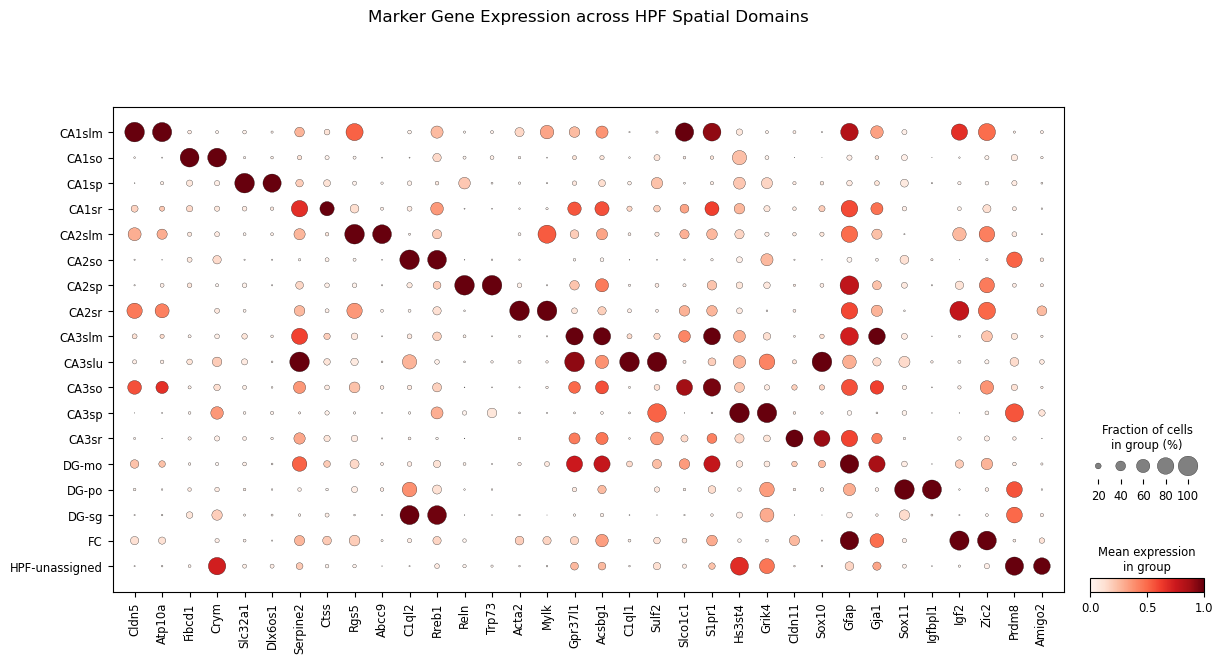

In [ ]:
# top genes heat map
top_genes = result_df.groupby('group').head(2)['gene_symbol'].unique()

sc.pl.dotplot(adata_new, 
              var_names=top_genes, 
              groupby='AW_HMRF_beta_20.0_named', 
              standard_scale='var', # 归一化，突出每个基因在哪个组表达最高
              title="Marker Gene Expression across HPF Spatial Domains")

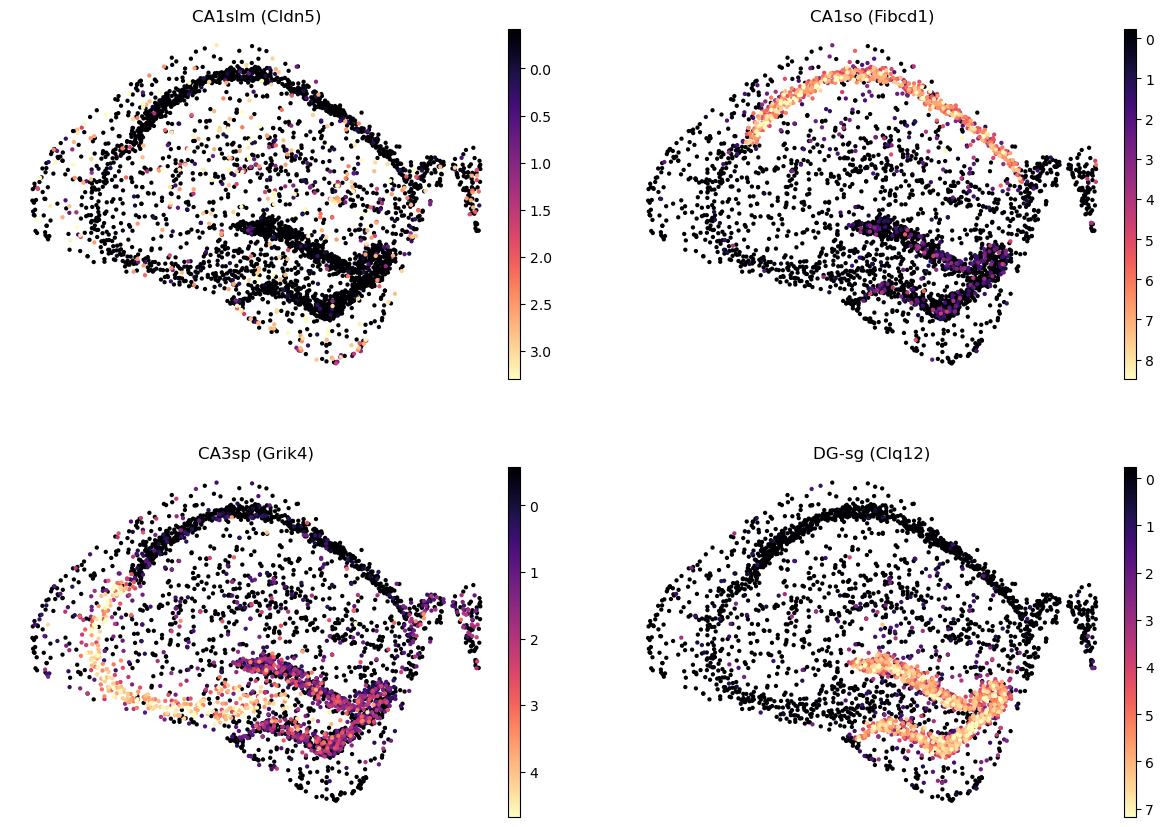

In [ ]:
import scanpy as sc

# 4 selected HPF marker genes expression plots
selected_markers = ['Cldn5', 'Fibcd1', 'Grik4', 'C1ql2']

sc.pl.embedding(
    adata_new, 
    basis='spatial', 
    color=selected_markers,
    ncols=2, 
    frameon=False,
    vmax='p99', 
    cmap='magma',
    title=[ 
        'CA1slm (Cldn5)', 
        'CA1so (Fibcd1)', 
        'CA3sp (Grik4)',
        'DG-sg (Clq12)'
    ],
    show = False
)

fig = plt.gcf()

for ax in fig.axes:
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymax, ymin)   

plt.show()

